**Title: Diabetes Prediction**

In [20]:
# Step 01: Importing libraries

# Diabetes Prediction System Using ANN

This project is based on Artificial Neural Networks (ANN) using PyTorch.

The objective of this project is to predict whether a patient has diabetes or not using medical health parameters.

The project uses the Pima Indians Diabetes Dataset from Kaggle and follows the complete Deep Learning workflow from preprocessing to prediction.

Features Used:
- Pregnancies
- Glucose
- Blood Pressure
- Skin Thickness
- Insulin
- BMI
- Diabetes Pedigree Function
- Age

Output:
- 0 → No Diabetes
- 1 → Diabetes

Project Workflow:
- Import Libraries
- Load Dataset
- Data Preprocessing
- Handle Missing Values
- Feature Selection
- Data Normalization
- Train-Test Split
- Tensor Conversion
- Dataset & DataLoader Creation
- ANN Model Building
- Define Loss Function
- Define Optimizer
- Training Loop
- Forward Propagation
- Backpropagation
- Weight Update
- Evaluation
- Accuracy Calculation
- Prediction
- Save Model

Technologies Used:
- Python
- PyTorch
- Pandas
- NumPy
- Scikit-learn
- Matplotlib

ANN Architecture:
Input Layer → Hidden Layer → Hidden Layer → Output Layer

Concepts Learned:
- Artificial Neural Networks
- Tensors
- Binary Classification
- Sigmoid Activation Function
- BCE Loss Function
- Forward Propagation
- Backward Propagation
- Optimizers
- Deep Learning Workflow

Future Improvements:
- Build Web Application
- Add Real-Time Prediction
- Deploy Using Flask/FastAPI
- Create Healthcare Dashboard
- Improve Model Accuracy

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [106]:
# step 02: load dataset

In [90]:
df = pd.read_csv("diabetes.csv")


In [ ]:
# step 03: Check dataset

In [91]:
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose             

In [ ]:
# step 04 Handling missing values

In [92]:
print(df.isnull().sum())

df = df.dropna()


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
# step 05 : Feature selection

In [93]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [ ]:
# step 07: Normalize data

In [94]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
# step 08: Split data into train and test

In [95]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# step 09: Convert into tensor

In [96]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)


In [ ]:
# step 10: Convert into dataset and data loader

In [97]:
class DiabetesDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]


train_dataset = DiabetesDataset(X_train, y_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)


In [ ]:
# step 11: Build an ANN model

In [98]:
class ANNModel(nn.Module):

    def __init__(self):
        super(ANNModel, self).__init__()

        self.fc1 = nn.Linear(8, 16)
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(16, 8)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)

        x = self.fc2(x)
        x = self.relu2(x)

        x = self.fc3(x)
        x = self.sigmoid(x)

        return x


model = ANNModel()
print(model)


ANNModel(
  (fc1): Linear(in_features=8, out_features=16, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=16, out_features=8, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [ ]:
# step 12: loss function

In [99]:
criterion = nn.BCELoss()


In [ ]:
# step 13: Define Optimizer

In [100]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
# step 14: Training loop

In [101]:
epochs = 100
losses = []

for epoch in range(epochs):

    model.train()
    epoch_loss = 0

    for inputs, targets in train_loader:

        inputs = inputs.float()
        targets = targets.float().view(-1, 1)

        # FORWARD PROPAGATION
        outputs = model(inputs)

        # LOSS CALCULATION
        loss = criterion(outputs, targets)

        # BACKWARD PROPAGATION
        optimizer.zero_grad()
        loss.backward()

        # WEIGHT UPDATE
        optimizer.step()

        epoch_loss += loss.item()

    losses.append(epoch_loss)

    print(f"Epoch [{epoch + 1}/{epochs}] Loss: {epoch_loss:.4f}")


Epoch [1/100] Loss: 25.7936
Epoch [2/100] Loss: 24.7955
Epoch [3/100] Loss: 23.7648
Epoch [4/100] Loss: 22.6733
Epoch [5/100] Loss: 21.4418
Epoch [6/100] Loss: 20.2226
Epoch [7/100] Loss: 19.4460
Epoch [8/100] Loss: 18.7531
Epoch [9/100] Loss: 18.1675
Epoch [10/100] Loss: 18.0290
Epoch [11/100] Loss: 18.1036
Epoch [12/100] Loss: 17.8972
Epoch [13/100] Loss: 17.4481
Epoch [14/100] Loss: 17.4157
Epoch [15/100] Loss: 17.2348
Epoch [16/100] Loss: 17.0783
Epoch [17/100] Loss: 17.5228
Epoch [18/100] Loss: 17.0833
Epoch [19/100] Loss: 16.9927
Epoch [20/100] Loss: 16.8906
Epoch [21/100] Loss: 16.8853
Epoch [22/100] Loss: 16.7475
Epoch [23/100] Loss: 16.6487
Epoch [24/100] Loss: 16.7258
Epoch [25/100] Loss: 16.8360
Epoch [26/100] Loss: 16.5610
Epoch [27/100] Loss: 16.7468
Epoch [28/100] Loss: 16.6709
Epoch [29/100] Loss: 16.4864
Epoch [30/100] Loss: 16.3413
Epoch [31/100] Loss: 16.4742
Epoch [32/100] Loss: 16.3815
Epoch [33/100] Loss: 16.2712
Epoch [34/100] Loss: 16.3320
Epoch [35/100] Loss: 16

In [ ]:
# step : Training loss

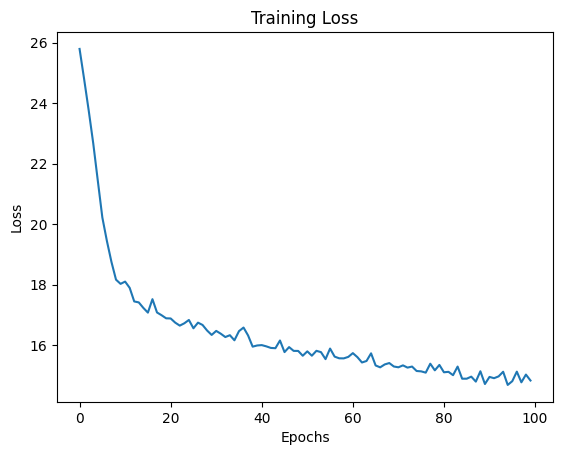

In [102]:
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [ ]:
# Step : Evaluation

In [103]:

model.eval()

with torch.no_grad():
    predictions = model(X_test)
    test_loss = criterion(predictions, y_test)

print("Test Loss:", test_loss.item())


Test Loss: 0.5823673605918884


In [ ]:
# Step : Accuracy

In [104]:
predicted = (predictions >= 0.5).float()

accuracy = (predicted == y_test).sum().item() / y_test.size(0)

print("Accuracy:", accuracy * 100)


Accuracy: 74.02597402597402


In [ ]:
# Step : Prediction

In [105]:

new_patient = np.array([
    [2, 120, 70, 20, 85, 28.5, 0.5, 30]
])

new_patient = scaler.transform(new_patient)

new_patient = torch.tensor(
    new_patient,
    dtype=torch.float32
)

model.eval()

with torch.no_grad():
    prediction = model(new_patient)
    predicted_class = (prediction >= 0.5).float()

print("Prediction Probability:", prediction.item())
print("Predicted Class:", int(predicted_class.item()))

if predicted_class.item() == 1:
    print("Result: Diabetic")
else:
    print("Result: Not Diabetic")


Prediction Probability: 0.19460174441337585
Predicted Class: 0
Result: Not Diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
